The metric we're going for here is 

>**$n*β^r/β$** 

where $β^r$ is the number of barys + oxys responsion groups, $β$ is the number of all barys + oxys accents in all strophes and $n$ is the number of strophes. 

In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Corpus

In [6]:
from aristophanis_cantica.stats_barys import barys_oxys_metric_corpus

corpus_dict = barys_oxys_metric_corpus(ROOT / 'data/compiled', exclude_substr='baseline')
barys_metric = corpus_dict['barys_metric']

print('WITH PL')
print(f'Barys corpus metric: \033[92m{barys_metric}\033[0m')

corpus_dict = barys_oxys_metric_corpus(ROOT / 'data/compiled/no_pl', exclude_substr='baseline')
barys_metric = corpus_dict['barys_metric']

print('\nWITHOUT PL')
print(f'Barys corpus metric: \033[92m{barys_metric}\033[0m')

WITH PL
Barys corpus metric: 0.43811807012286486

WITHOUT PL
Barys corpus metric: 0.4348091603053435


# Play regression

In [3]:
from aristophanis_cantica.stats_barys import barys_oxys_metric_play
from aristophanis_cantica.utils.utils import abbreviations

play_dict_barys = {}
for play in abbreviations: 
    play_dict_barys[play] = barys_oxys_metric_play(play)
    barys_results = play_dict_barys[play]["barys_metric"]
    print(f'{play}: {barys_results}')

abbreviations_no_pl = [abbrev for abbrev in abbreviations if abbrev != 'pl']

play_dict_barys_no_pl = {}
for play in abbreviations_no_pl: 
    play_dict_barys_no_pl[play] = barys_oxys_metric_play(play)


ach: 0.43340857787810383
eq: 0.45965770171149145
nu: 0.5118483412322274
v: 0.4558139534883721
pax: 0.46397694524495675
av: 0.4578313253012048
lys: 0.33587786259541985
th: 0.5272727272727272
ra: 0.3647342995169082
ec: 0.46236559139784944
pl: 0.6129032258064516


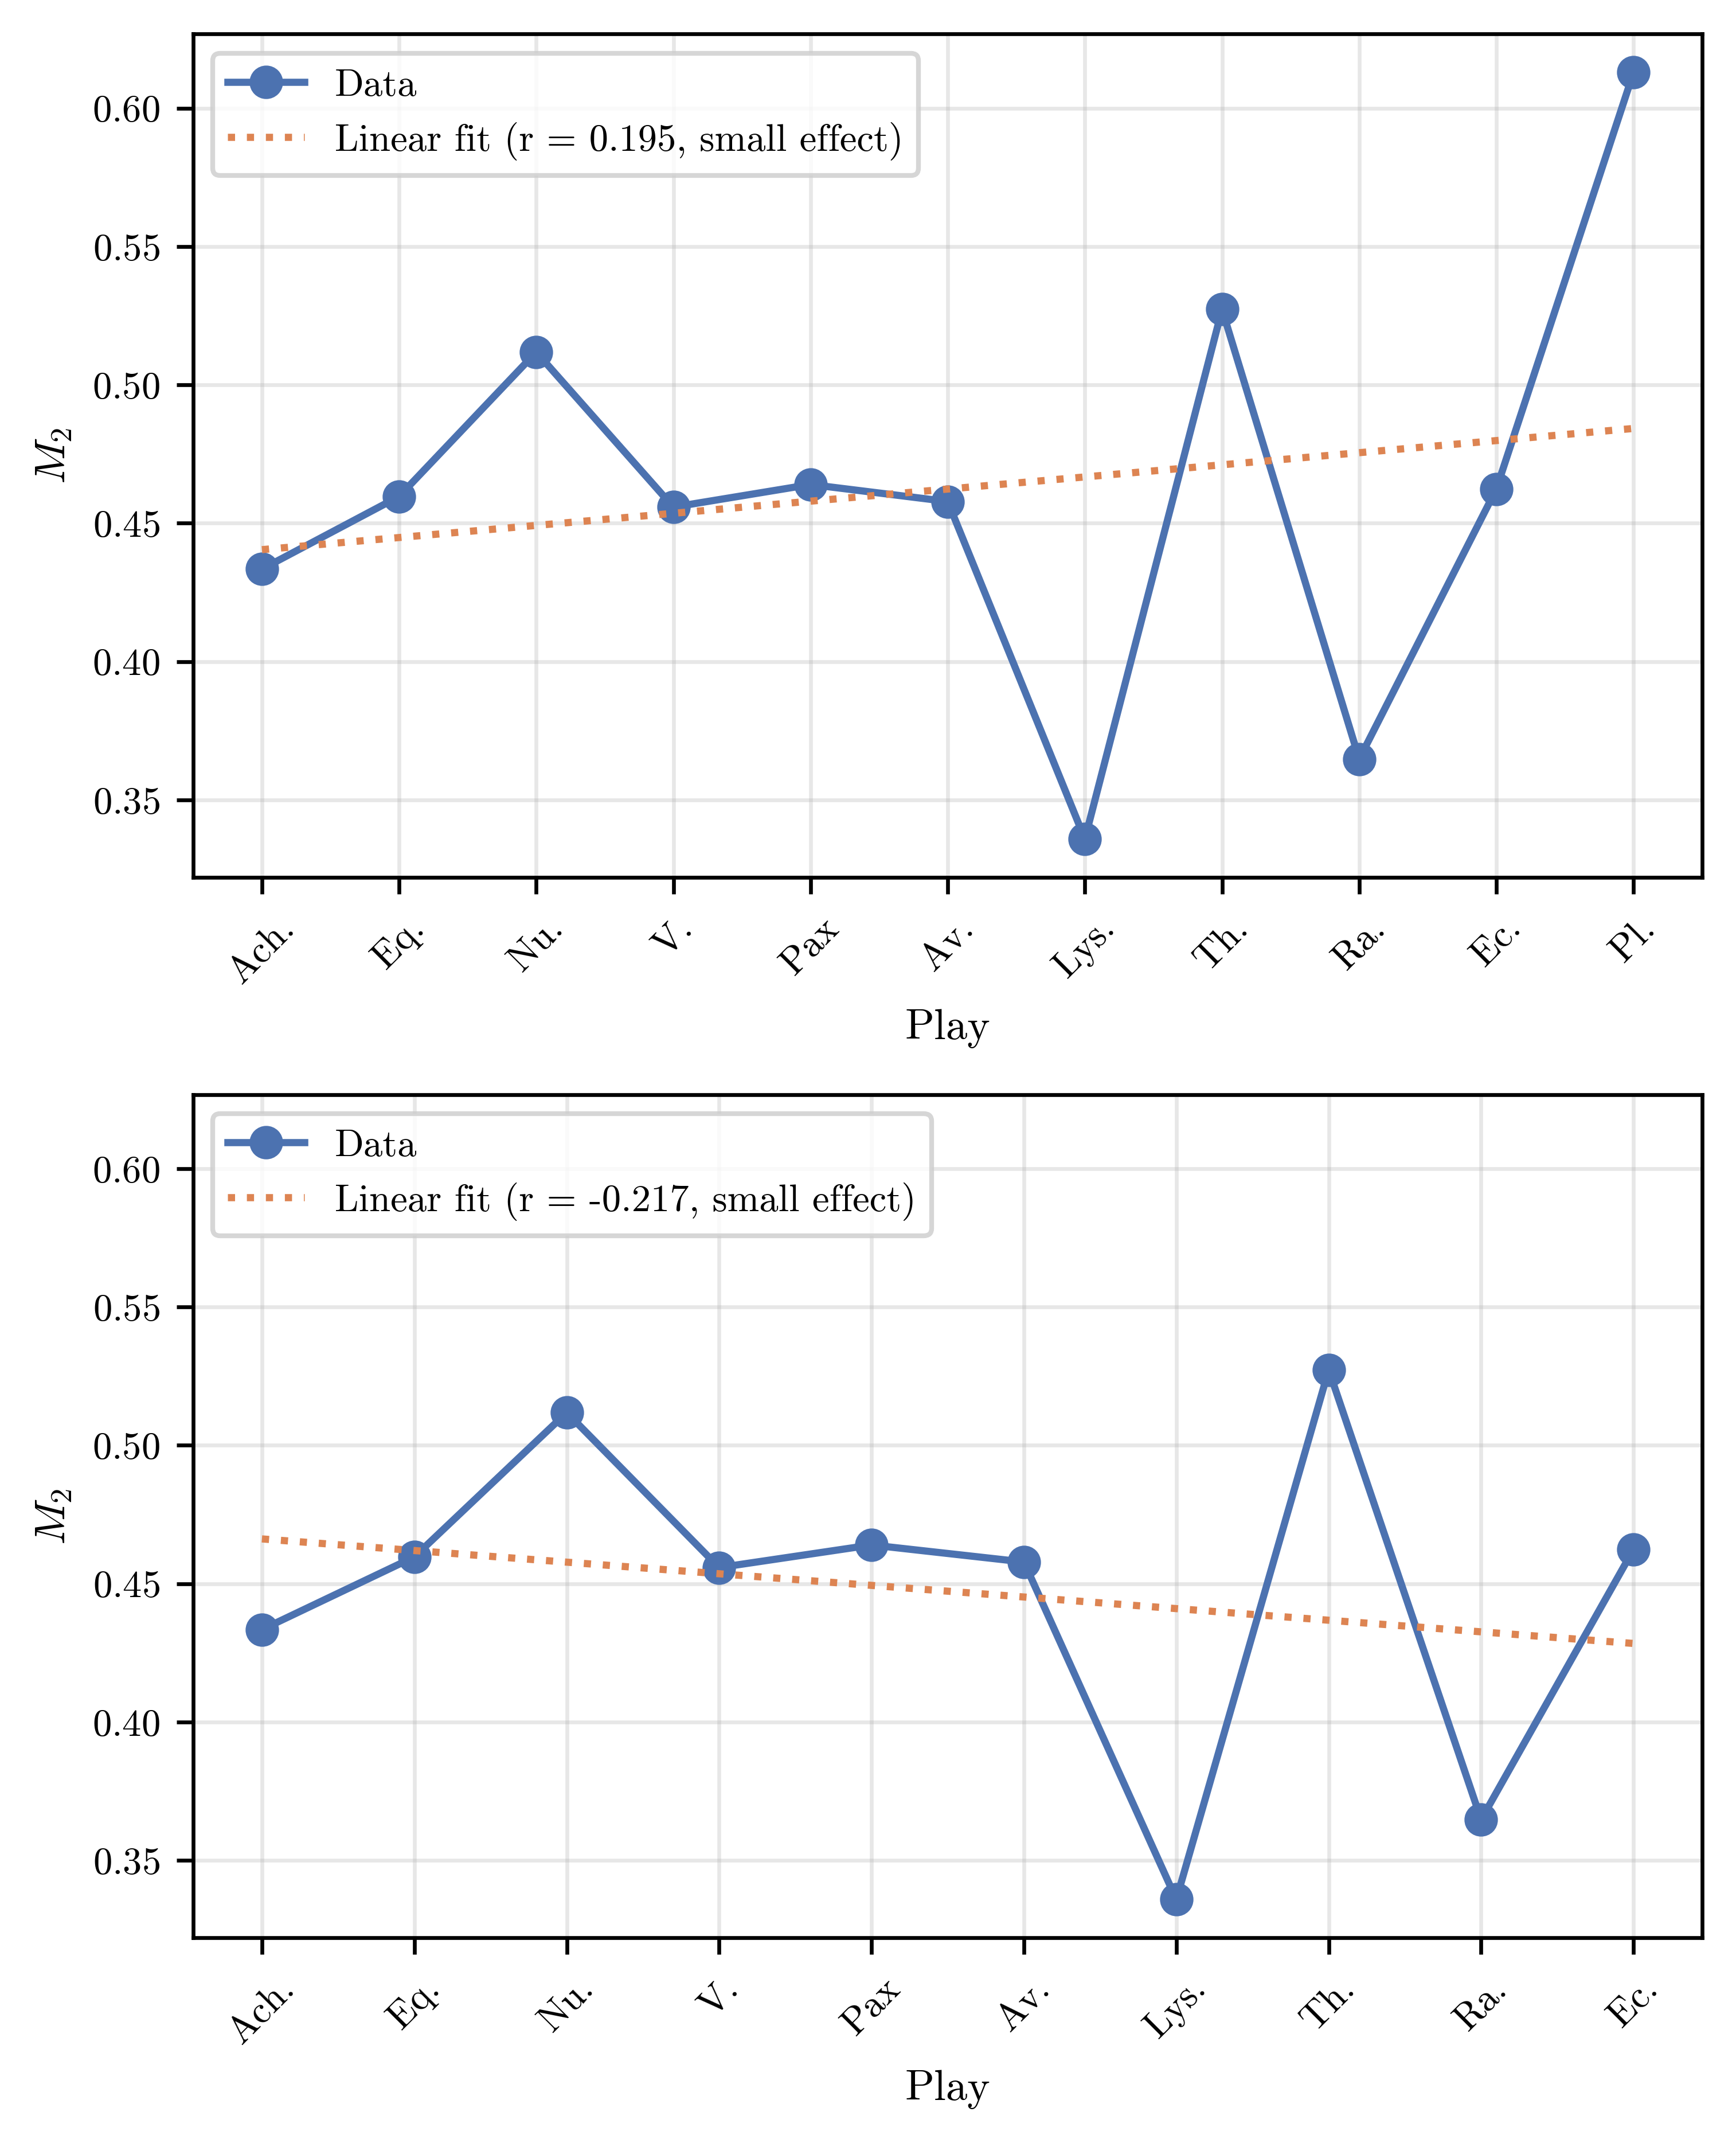

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

from aristophanis_cantica.plot import apply_plotting_poetry_palette_stacked
from aristophanis_cantica.utils.utils import get_cohen_category, abbreviations_fancy

apply_plotting_poetry_palette_stacked()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# ----------------------------
# Build datasets
# ----------------------------
data_with_pl = {
    k: play_dict_barys[k]["barys_metric"]
    for k in play_dict_barys
}

data_without_pl = {
    k: play_dict_barys_no_pl[k]["barys_metric"]
    for k in play_dict_barys_no_pl
}


# ----------------------------
# Figure layout (matches example)
# ----------------------------
fig, axes = plt.subplots(2, 1, sharey=True)


# ----------------------------
# Top plot: with Pl.
# ----------------------------
x = list(range(len(data_with_pl)))
labels = [abbreviations_fancy.get(k, k) for k in data_with_pl]
y = [float(v) for v in data_with_pl.values()]

slope, intercept, r_value, *_ = linregress(x, y)
regression_line = [slope * xi + intercept for xi in x]

axes[0].plot(
    x,
    y,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[0].plot(
    x,
    regression_line,
    color=default_colors[1],
    linestyle=":",
    label=f"Linear fit (r = {r_value:.3f}, {get_cohen_category(r_value)} effect)",
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45)
axes[0].set_xlabel("Play")
axes[0].set_ylabel("$M_2$")
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# ----------------------------
# Bottom plot: without Pl.
# ----------------------------
x = list(range(len(data_without_pl)))
labels = [abbreviations_fancy.get(k, k) for k in data_without_pl]
y = [float(v) for v in data_without_pl.values()]

slope, intercept, r_value, *_ = linregress(x, y)
regression_line = [slope * xi + intercept for xi in x]

axes[1].plot(
    x,
    y,
    marker="o",
    color=default_colors[0],
    label="Data"
)

axes[1].plot(
    x,
    regression_line,
    color=default_colors[1],
    linestyle=":",
    label=f"Linear fit (r = {r_value:.3f}, {get_cohen_category(r_value)} effect)",
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45)
axes[1].set_xlabel("Play")
axes[1].set_ylabel("$M_2$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")


plt.tight_layout()
plt.savefig(
    ROOT / "media/play_regression/linreg_barys.png",
    dpi=600
)
plt.show()

# Detailed

In [5]:
from lxml import etree

from aristophanis_cantica.stats_barys import barys_accentually_responding_syllables_of_strophes_polystrophic, count_all_barys_oxys_canticum

from aristophanis_cantica.utils.utils import abbreviations, get_canticum_ids, polystrophic_cantica

def barys_detailed_print(infix):

    input_file = ROOT / f"data/compiled/responsion_{infix}_compiled.xml"
    tree = etree.parse(input_file)

    canticum_ids = get_canticum_ids([infix])

    for responsion in canticum_ids:
        print(f"\nCanticum: {responsion}")
            
        all_barys_oxys_canticum_dict = count_all_barys_oxys_canticum(tree, responsion)
        print(all_barys_oxys_canticum_dict)
        sum_barys = all_barys_oxys_canticum_dict['barys']
        sum_oxys = all_barys_oxys_canticum_dict['oxys']
        sum_barys_oxys = sum_barys + sum_oxys

        strophes = tree.xpath(f'//strophe[@responsion="{responsion}"] | //antistrophe[@responsion="{responsion}"]') # bug fix (was only strophe)
        n = len(strophes)

        barys_oxys_results = barys_accentually_responding_syllables_of_strophes_polystrophic(*strophes)

        if not barys_oxys_results:
            print("No valid barys/oxys matches found.\n")
            continue  # Skip to next responsion if no results

        barys_list, oxys_list = barys_oxys_results

        print(f"Barys matches: {len(barys_list)}")
        print(f"Oxys matches:  {len(oxys_list)}\n")

        barys_metric = (n * len(barys_list)) / sum_barys if sum_barys > 0 else 0
        oxys_metric = (n * len(oxys_list)) / sum_oxys if sum_oxys > 0 else 0
        barys_oxys_metric = (n * (len(barys_list) + len(oxys_list))) / sum_barys_oxys if sum_barys_oxys > 0 else 0

        print(f"Barys metric: {barys_metric:.3f}")
        print(f"Oxys metric:  {oxys_metric:.3f}")
        print(f"Barys + Oxys metric: {barys_oxys_metric:.3f}\n")

        if responsion in polystrophic_cantica:
            if barys_list:
                print("--- BARYS MATCHES ---")
                for match_idx, match_set in enumerate(barys_list, start=1):
                    print(f"  Match #{match_idx}:")
                    for (line_id, unit_ord), text in match_set.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

            if oxys_list:
                print("--- OXYS MATCHES ---")
                for match_idx, match_set in enumerate(oxys_list, start=1):
                    print(f"  Match #{match_idx}:")
                    for (line_id, unit_ord), text in match_set.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()
            
        else: 
            if barys_list:
                print("--- BARYS MATCHES ---")
                for i, pair_dict in enumerate(barys_list, start=1):
                    print(f"  Pair #{i}:")
                    for (line_id, unit_ord), text in pair_dict.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

            if oxys_list:
                print("--- OXYS MATCHES ---")
                for i, pair_dict in enumerate(oxys_list, start=1):
                    print(f"  Pair #{i}:")
                    for (line_id, unit_ord), text in pair_dict.items():
                        print(f"    (line {line_id}, ord={unit_ord}) => \"{text}\"")
                    print()

for infix in abbreviations:
    barys_detailed_print(infix)


Canticum: ach01
{'barys': 67, 'oxys': 26}
Barys matches: 15
Oxys matches:  2

Barys metric: 0.448
Oxys metric:  0.154
Barys + Oxys metric: 0.366

--- BARYS MATCHES ---
  Pair #1:
    (line 204, ord=1) => "Τῇ"
    (line 219, ord=1) => "Νῦν"

  Pair #2:
    (line 205, ord=8) => "πάντων"
    (line 220, ord=8) => "τείδῃ"

  Pair #3:
    (line 205, ord=11) => "πόλει"
    (line 220, ord=11) => "κέλος"

  Pair #4:
    (line 206, ord=7) => "τοῦ"
    (line 221, ord=7) => "τέος"

  Pair #5:
    (line 207, ord=3) => "οἶ"
    (line 222, ord=3) => "δέπερ"

  Pair #6:
    (line 207, ord=5) => "δ' ὅποι"
    (line 222, ord=5) => "γέρον"

  Pair #7:
    (line 207, ord=15) => "φέρων"
    (line 222, ord=15) => "νέας"

  Pair #8:
    (line 208-209, ord=3) => "πέφευγ"
    (line 223-224, ord=3) => "ς, ὦ Ζ"

  Pair #9:
    (line 210-211, ord=4) => "ς. Οἴμοι"
    (line 225, ord=4) => "τοῖ"

  Pair #10:
    (line 210-211, ord=7) => "τῶν"
    (line 225, ord=7) => "θροῖ"

  Pair #11:
    (line 211-212, ord=4) =